In [9]:
%pip install pandas numpy matplotlib --quiet


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
# Import necessary libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'svg'

print("Libraries imported successfully!")

# Connect to the SQLite database
conn = sqlite3.connect("inventory.db")

# Create a cursor object to interact with the database
cursor = conn.cursor()

# Function to run a SQL query and return the results as a DataFrame
def run_query_to_df(cursor, query):
    cursor.execute(query)
    rows = cursor.fetchall()
    
    # Get column names from cursor
    columns = []
    for col in cursor.description:
        columns.append(col[0])

    # Convert to DataFrame
    df = pd.DataFrame(rows, columns = columns)

    return df

Libraries imported successfully!


In [13]:
# Only keeps category-region combinations with at least 10 orders, so the average delay is more reliable.
# order_region is now a column on the orders table; product link goes through order_items.
query = """
SELECT c.category_name,
       o.order_region AS region,
       AVG(s.days_actual - s.days_scheduled) AS avg_delay,
       COUNT(DISTINCT o.id) AS number_of_orders
FROM orders AS o
JOIN order_items AS oi ON o.id = oi.order_id
JOIN shipping    AS s  ON o.id = s.order_id
JOIN products    AS p  ON oi.product_id = p.id
JOIN categories  AS c  ON p.category_id = c.id
GROUP BY c.category_name, o.order_region
HAVING COUNT(DISTINCT o.id) >= 10
ORDER BY avg_delay DESC
"""

result = run_query_to_df(cursor, query)
result["avg_delay"] = result["avg_delay"].round(2)
result

,category_name,region,avg_delay,number_of_orders
0,Soccer,South America,1.73,11
1,Hockey,South Asia,1.54,26
2,Accessories,North Africa,1.51,41
3,As Seen on TV!,South America,1.50,10
4,Lacrosse,East of USA,1.46,13
...,...,...,...,...
602,Basketball,Southern Europe,-0.17,12
603,Lacrosse,Southern Europe,-0.20,19
604,Soccer,Caribbean,-0.20,10
605,Tennis & Racquet,South Asia,-0.31,13


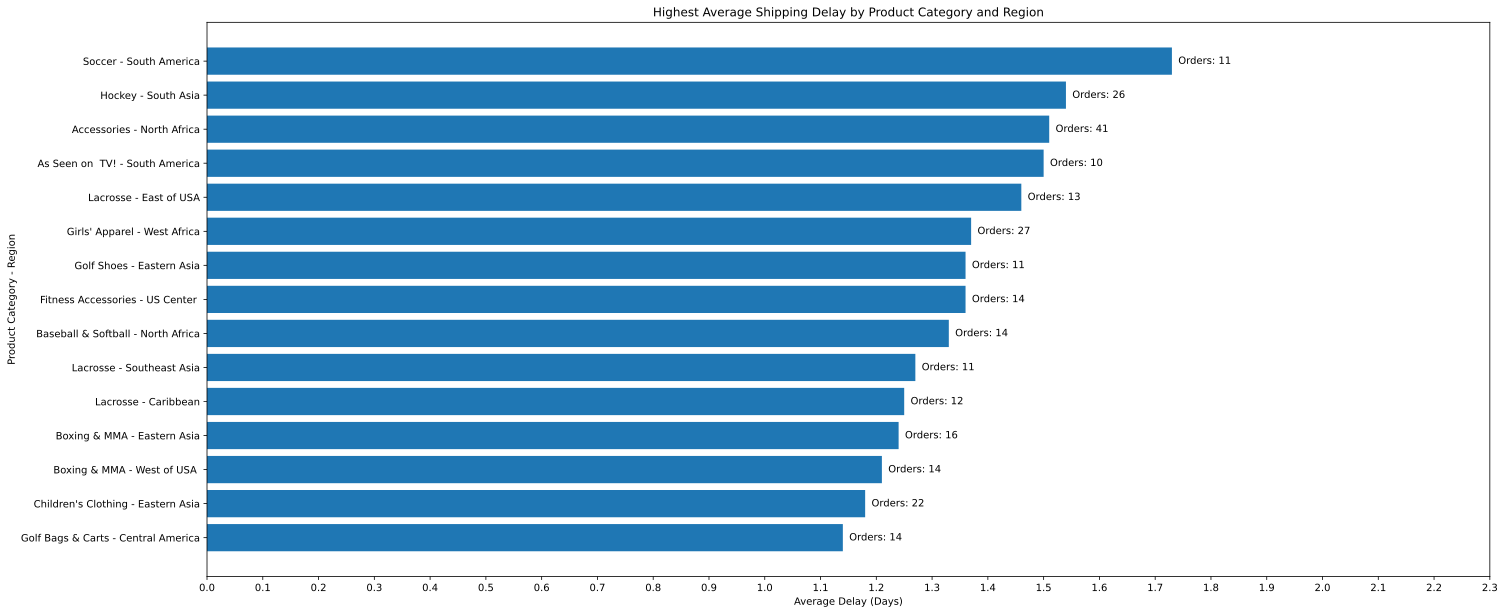

In [14]:
top = result.head(15)

top["combo"] = top["category_name"] + " - " + top["region"]

plt.figure(figsize=(23, 10))

bars = plt.barh(top["combo"], top["avg_delay"])

plt.xlabel("Average Delay (Days)")
plt.ylabel("Product Category - Region")
plt.title("Highest Average Shipping Delay by Product Category and Region")

for i in range(len(top)):
    plt.text(top["avg_delay"].iloc[i],
             i,
             "  Orders: " + str(top["number_of_orders"].iloc[i]),
             va="center")

plt.xticks(np.arange(0, 2.4, 0.1))

plt.gca().invert_yaxis()
plt.show()